In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_parquet('C:/Users/artem/Downloads/MLOps/Used Car Project/data/processed/full_dataset.parquet')

# Downsample to 20% to iterate quickly in the notebook
# df = df.sample(frac=0.2, random_state=42)
# print(f"Experimentation shape: {df.shape}")

X = df.drop(columns=['sellingprice', 'mmr'])
y = df['sellingprice']

# Convert strings to 'category' dtype for LightGBM and XGBoost
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# X.head()

Train size: 405806 | Test size: 101452


In [9]:
def evaluate(model_name, y_true, y_pred_log):
    # Reverse the log1p transformation
    y_pred = np.expm1(y_pred_log)
    
    # Prevent negative predictions
    y_pred = np.clip(y_pred, 0, None)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"R²:   {r2:.4f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAE:  {mae:,.2f}\n")

In [ ]:
print("Training LightGBM...")
lgbm = LGBMRegressor(
    n_estimators=200, 
    max_depth=8,
    learning_rate=0.05, 
    random_state=42,
    n_jobs=-1
)

# Fit on log-transformed target
lgbm.fit(X_train, np.log1p(y_train))

# Predict and evaluate
lgbm_preds_log = lgbm.predict(X_test)
evaluate("LightGBM", y_test, lgbm_preds_log)

Training LightGBM...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007952 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6346
[LightGBM] [Info] Number of data points in the train set: 405806, number of used features: 14
[LightGBM] [Info] Start training from score 9.216023
--- LightGBM ---
R²:   0.9097
RMSE: 2,894.56
MAE:  1,693.00



In [ ]:
print("Training XGBoost...")
xgb = XGBRegressor(
    n_estimators=150, 
    max_depth=8, 
    learning_rate=0.05, 
    random_state=42, 
    enable_categorical=True,
    n_jobs=-1
)

# Fit on log-transformed target
xgb.fit(X_train, np.log1p(y_train))

# Predict and evaluate
xgb_preds_log = xgb.predict(X_test)
evaluate("XGBoost", y_test, xgb_preds_log)

Training XGBoost...
--- XGBoost ---
R²:   0.9293
RMSE: 2,560.46
MAE:  1,565.94



In [39]:
# optuna params: {'n_estimators': 443, 'max_depth': 12, 'learning_rate': 0.07738560131240116, 'num_leaves': 129, 'subsample': 0.8294967332251209, 'colsample_bytree': 0.6755956823271021}
# Best LightGBM RMSE (Log Scale): 0.2573

# the final selected params
print("Training LightGBM...")
lgbm = LGBMRegressor(
    n_estimators=450, 
    max_depth=12,
    learning_rate=0.08, 
    num_leaves=129,
    subsample=0.8,
    colsample_bytree=0.75,
    random_state=42,
    n_jobs=-1
)

# Fit on log-transformed target
lgbm.fit(X_train, np.log1p(y_train))

# Predict and evaluate
lgbm_preds_log = lgbm.predict(X_test)
evaluate("LightGBM", y_test, lgbm_preds_log)

Training LightGBM...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008516 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6346
[LightGBM] [Info] Number of data points in the train set: 405806, number of used features: 14
[LightGBM] [Info] Start training from score 9.216023
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
--- LightGBM ---
R²:   0.9327
RMSE: 2,499.16
MAE:  1,432.93



In [ ]:
# optuna parms: {'n_estimators': 446, 'max_depth': 10, 'learning_rate': 0.07944346441464045, 'subsample': 0.7343262316005394, 'colsample_bytree': 0.9075942287298807, 'min_child_weight': 4}
# Best XGBoost RMSE (Log Scale): 0.2626

# the final selected params
print("Training XGBoost...")
xgb = XGBRegressor(
    n_estimators=450, 
    max_depth=10, 
    learning_rate=0.08,
    subsample=0.75,
    colsample_bytree=0.9,
    min_child_weight=4,
    random_state=42, 
    enable_categorical=True,
    n_jobs=-1
)

# Fit on log-transformed target
xgb.fit(X_train, np.log1p(y_train))

# Predict and evaluate
xgb_preds_log = xgb.predict(X_test)
evaluate("XGBoost", y_test, xgb_preds_log)

Training XGBoost...
--- XGBoost ---
R²:   0.9396
RMSE: 2,367.34
MAE:  1,416.79



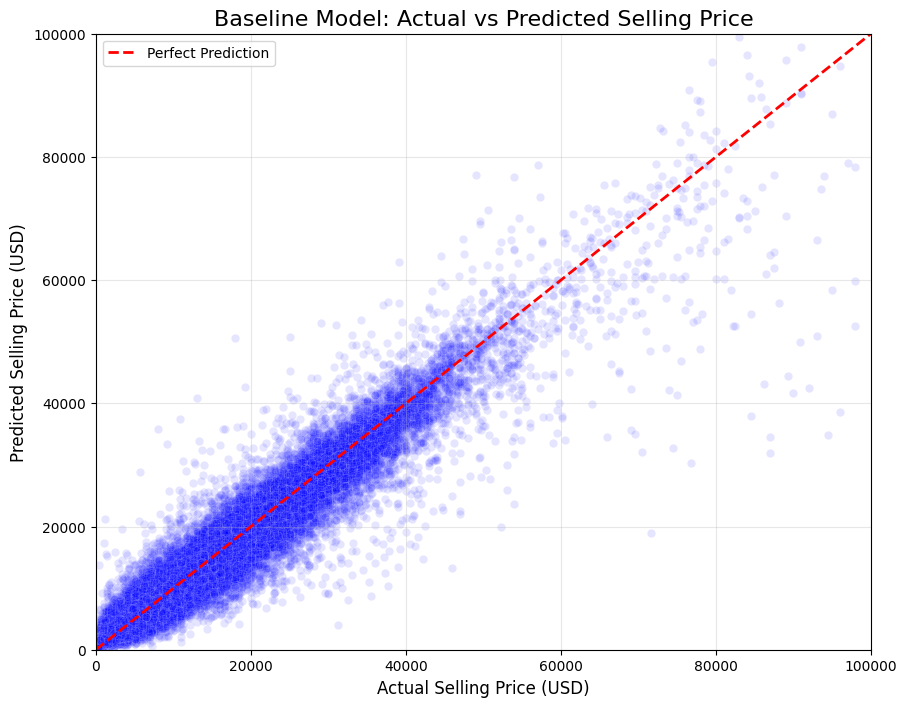

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Use a scatter plot with high transparency (alpha) to handle dense data points
sns.scatterplot(x=y_test, y=np.expm1(lgbm_preds_log), alpha=0.1, color="blue")

# Add a red diagonal line showing where "Perfect Predictions" would fall
max_val = min(y_test.max(), 100000) # Cap the chart at 100k for readability
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# Formatting
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.title('Baseline Model: Actual vs Predicted Selling Price', fontsize=16)
plt.xlabel('Actual Selling Price (USD)', fontsize=12)
plt.ylabel('Predicted Selling Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

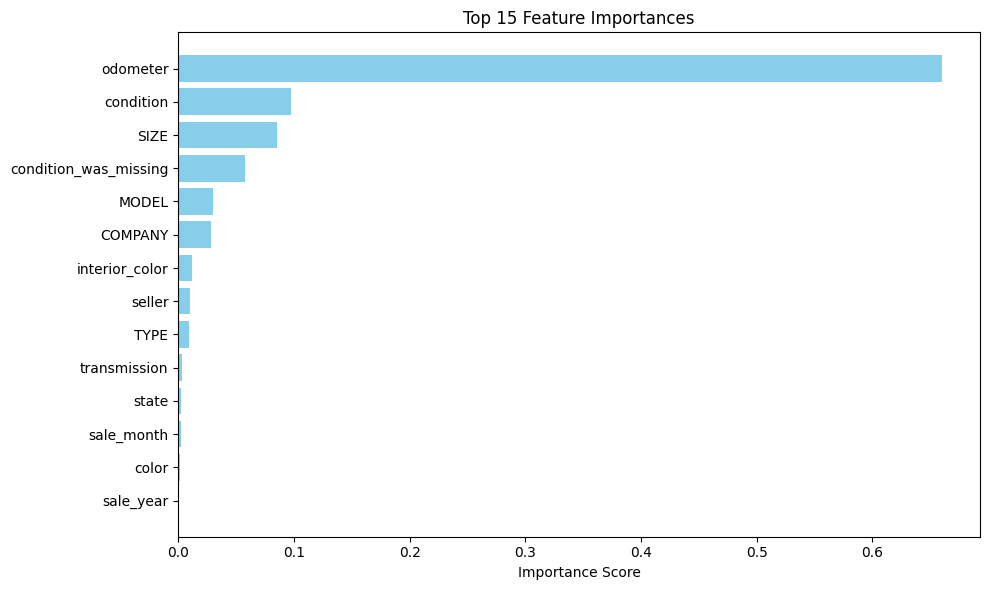

In [ ]:
import matplotlib.pyplot as plt

# Change to lgbm if LightGBM performs better
best_model = xgb 

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'][::-1], importance['Importance'][::-1], color='skyblue')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
import optuna
from sklearn.metrics import mean_squared_error

# Create a validation set exclusively for Optuna to avoid touching X_test
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Log-transform targets once to save computation time inside the loops
y_tr_log = np.log1p(y_tr)
y_val_log = np.log1p(y_val)

In [29]:
def objective_lgbm(trial):
    # 1. Define the hyperparameter search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    
    # 2. Initialize and train the model
    model = LGBMRegressor(**params)
    model.fit(X_tr, y_tr_log)
    
    # 3. Predict and calculate RMSE
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val_log, preds))
    
    return rmse

print("Starting LightGBM Optuna Study...")
# Create a study object and optimize the objective function
study_lgbm = optuna.create_study(direction='minimize', study_name="LGBM_Tuning")
study_lgbm.optimize(objective_lgbm, n_trials=50)  # Increase n_trials to 50+ for a real search

print("\nBest LightGBM Parameters:")
print(study_lgbm.best_params)
print(f"Best LightGBM RMSE (Log Scale): {study_lgbm.best_value:.4f}")

[I 2026-07-18 15:04:00,383] A new study created in memory with name: LGBM_Tuning


Starting LightGBM Optuna Study...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008480 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6320
[LightGBM] [Info] Number of data points in the train set: 324644, number of used features: 14
[LightGBM] [Info] Start training from score 9.215456
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

[I 2026-07-18 15:04:03,087] Trial 0 finished with value: 0.27483553027332164 and parameters: {'n_estimators': 301, 'max_depth': 5, 'learning_rate': 0.09180732884318399, 'num_leaves': 27, 'subsample': 0.6289125715704323, 'colsample_bytree': 0.8468432382133433}. Best is trial 0 with value: 0.27483553027332164.


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009762 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6320
[LightGBM] [Info] Number of data points in the train set: 324644, number of used features: 14
[LightGBM] [Info] Start training from score 9.215456
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

[I 2026-07-18 15:04:06,626] Trial 1 finished with value: 0.3200603734602294 and parameters: {'n_estimators': 289, 'max_depth': 5, 'learning_rate': 0.016055750843810623, 'num_leaves': 146, 'subsample': 0.8352054834974926, 'colsample_bytree': 0.9277874106306316}. Best is trial 0 with value: 0.27483553027332164.


...

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6320
[LightGBM] [Info] Number of data points in the train set: 324644, number of used features: 14
[LightGBM] [Info] Start training from score 9.215456
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

[I 2026-07-18 15:08:19,483] Trial 48 finished with value: 0.27960066028967606 and parameters: {'n_estimators': 416, 'max_depth': 6, 'learning_rate': 0.0295086837215347, 'num_leaves': 117, 'subsample': 0.6606876474473197, 'colsample_bytree': 0.6371296180215988}. Best is trial 35 with value: 0.2573003737228518.


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006104 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6320
[LightGBM] [Info] Number of data points in the train set: 324644, number of used features: 14
[LightGBM] [Info] Start training from score 9.215456
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

[I 2026-07-18 15:08:25,769] Trial 49 finished with value: 0.25946396224109003 and parameters: {'n_estimators': 451, 'max_depth': 12, 'learning_rate': 0.04109425818462828, 'num_leaves': 150, 'subsample': 0.7633814304301807, 'colsample_bytree': 0.6695564179157623}. Best is trial 35 with value: 0.2573003737228518.



Best LightGBM Parameters:
{'n_estimators': 443, 'max_depth': 12, 'learning_rate': 0.07738560131240116, 'num_leaves': 129, 'subsample': 0.8294967332251209, 'colsample_bytree': 0.6755956823271021}
Best LightGBM RMSE (Log Scale): 0.2573


In [31]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'enable_categorical': True, # Crucial for XGBoost
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = XGBRegressor(**params)
    model.fit(X_tr, y_tr_log)
    
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val_log, preds))
    
    return rmse

print("Starting XGBoost Optuna Study...")
study_xgb = optuna.create_study(direction='minimize', study_name="XGB_Tuning")
study_xgb.optimize(objective_xgb, n_trials=20) 

print("\nBest XGBoost Parameters:")
print(study_xgb.best_params)
print(f"Best XGBoost RMSE (Log Scale): {study_xgb.best_value:.4f}")

[I 2026-07-18 15:23:29,821] A new study created in memory with name: XGB_Tuning


Starting XGBoost Optuna Study...


[I 2026-07-18 15:23:33,230] Trial 0 finished with value: 0.2792535131755562 and parameters: {'n_estimators': 178, 'max_depth': 6, 'learning_rate': 0.15172580398289143, 'subsample': 0.6414318646955082, 'colsample_bytree': 0.8269755311985494, 'min_child_weight': 9}. Best is trial 0 with value: 0.2792535131755562.
[I 2026-07-18 15:23:41,237] Trial 1 finished with value: 0.26887140774233204 and parameters: {'n_estimators': 252, 'max_depth': 8, 'learning_rate': 0.10128817454330348, 'subsample': 0.6694500833891291, 'colsample_bytree': 0.793910902002358, 'min_child_weight': 5}. Best is trial 1 with value: 0.26887140774233204.
[I 2026-07-18 15:23:47,762] Trial 2 finished with value: 0.2691297852769066 and parameters: {'n_estimators': 174, 'max_depth': 9, 'learning_rate': 0.1367757091031981, 'subsample': 0.6279295820402582, 'colsample_bytree': 0.7783835788427186, 'min_child_weight': 7}. Best is trial 1 with value: 0.26887140774233204.
[I 2026-07-18 15:23:56,914] Trial 3 finished with value: 0.2


Best XGBoost Parameters:
{'n_estimators': 446, 'max_depth': 10, 'learning_rate': 0.07944346441464045, 'subsample': 0.7343262316005394, 'colsample_bytree': 0.9075942287298807, 'min_child_weight': 4}
Best XGBoost RMSE (Log Scale): 0.2626


In [30]:
# Example: Retraining the best LightGBM model
print("Retraining LightGBM with optimal hyperparameters...")

best_lgbm_params = study_lgbm.best_params
# Add back the static parameters that Optuna didn't tune
best_lgbm_params['random_state'] = 42
best_lgbm_params['n_jobs'] = -1

final_lgbm = LGBMRegressor(**best_lgbm_params)
final_lgbm.fit(X_train, np.log1p(y_train))

final_preds = final_lgbm.predict(X_test)
evaluate("Optimized LightGBM", y_test, final_preds)

Retraining LightGBM with optimal hyperparameters...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007997 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6346
[LightGBM] [Info] Number of data points in the train set: 405806, number of used features: 14
[LightGBM] [Info] Start training from score 9.216023
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [33]:
# Example: Retraining the best XGBoost model
print("Retraining XGBoost with optimal hyperparameters...")

best_xgb_params = study_xgb.best_params

# Add back the static parameters that Optuna didn't tune
best_xgb_params['random_state'] = 42
best_xgb_params['n_jobs'] = -1
best_xgb_params['enable_categorical'] = True  # CRUCIAL: Must be added back!

# Pass the correct dictionary (best_xgb_params, not best_lgbm_params)
final_xgb = XGBRegressor(**best_xgb_params)
final_xgb.fit(X_train, np.log1p(y_train))

final_preds = final_xgb.predict(X_test)

# Update the label so your printout makes sense
evaluate("Optimized XGBoost", y_test, final_preds)

Retraining XGBoost with optimal hyperparameters...
--- Optimized XGBoost ---
R²:   0.9397
RMSE: 2,364.62
MAE:  1,419.24

